# $\color{orange}{\text{Chapter 11 of "Statistical Physics"}}$
# $\color{orange}{\text{Paragraph 11.2: EOS of an Ideal Fermi Gas}}$

 
Author: Jan Ryckebusch (notebook version September 2019, major additions December 2022)

This is an ipynb (Jupyter notebook) that visualizes the $f_{3/2}(z)$ function and many other features (like entropy, specific heat, EOS, $\ldots$) of an Ideal Fermi Gas
  

In [8]:
from scipy import integrate
import math as m

import matplotlib.pyplot as plt # matplotlib: nice & quick figures
#----------------------------------------------------------------------
# tweak the parameters of the plots ...
# nothing essential, makes things look nicer ...
#
params = {'legend.fontsize' : 20,
          'axes.linewidth'  : 2.5,
          'axes.labelsize'  : 20,
          'lines.linewidth' : 2, 
          
          'xtick.major.width' : 3,
          'xtick.major.size'  : 12,
          'ytick.major.width' : 3,
          'ytick.major.size'  : 12,
          'xtick.major.pad'  : 10,
          'xtick.minor.width' : 2,
          'xtick.minor.size'  : 6,
          'ytick.minor.width' : 2,
          'ytick.minor.size'  : 6,
          'xtick.labelsize'    : 18,
          'ytick.labelsize'    : 18 }
plt.rcParams['text.latex.preamble']=[r"\usepackage{amsmath} \usepackage{amssymb} \usepackage{amsfonts} \boldmath"]
plt.rcParams.update(params)
plt.rc("font",family="serif",weight='bold')
# at this point parameters for the figures are set

In [9]:
# the f_{3/2}(z) function
#  low z (classical limit) via a series expansion
#  high z (quantum limit) by means of the Sommerfeld technique
#  full z range: via the integral over the dimensionless quantity x

# f32 as a function of the fugacity z and the momentum x 
f32 = lambda x, z : 4./m.sqrt(m.pi)*x**2/(1+m.exp(x**2)/z)

# low-z limit of f32: retain all terms in the fugacity up to the third order
xlow = lambda z : z - z**2/(2.)**(3./2.) + z**3/(3.)**(3./2.)

# high-z limit of f32
xhigh = lambda z : 4./(3.*m.sqrt(m.pi))*((m.log(z))**(3./2.)  
                    + (m.pi)**2/8.*(m.log(z))**(-1./2.))

In [10]:
# create the lists and open file for results (if required)
F32EXACT=[] ; F32LOW=[] ; F32HIGH=[] ; FUGACITY=[]
 
xx=0.1
while xx < 10.:
    FUGACITY.append(xx)
# integrate.quad solves one-dimensional integrals
#  \int _ {x_0} ^{x_1} f(x) dx = integrate.quad(f,x_0,x_1)[0]
#     koed=integrate.quad(f32,0.,Integrate.Inf)[0]: error with ranges ...
    z=xx
# args=(): extra arguments to pass to function
# the integration over the momentum from zero to p_{upper}
#   convergence is reached for p_{upper} \approx 10
    koed=integrate.quad(f32,0.,10.,args=(z))[0]
    koee=xlow(xx)
    koef=100.
# high z approximation requires z>1
    if xx> 1.2:
        koef=xhigh(xx)
#
    F32EXACT.append(koed)
    F32LOW.append(koee)
    F32HIGH.append(koef)
#    print xx,koed,koee,koef
    txt = str(xx)+ "\t" + str(koed) + "\t"+ str(koee) + "\t" + str(koef) + "\n"
#    f32results.write(txt) # write results to a file
    xx=xx+0.1
#
# f32results.close() # close the file 


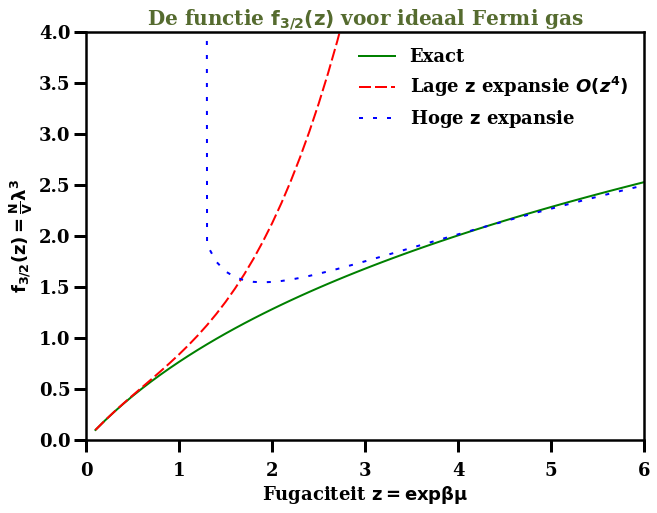

In [11]:
# create the plot with the f_{3/2}(z) function (compare exact with low and high z approximation)

fig1=plt.figure(figsize=(10,7.5))
ax1=fig1.add_subplot(111)
ax1.plot(FUGACITY, F32EXACT, "g-",linewidth=2,label=r'Exact')
ax1.plot(FUGACITY, F32LOW  , color='red',dashes=[6,2],linewidth=2,label=r'Lage $\bf z$ expansie $O(z^4)$')    
ax1.plot(FUGACITY, F32HIGH , color='blue', dashes=[2,5],linewidth=2,label=r'Hoge $\bf z$ expansie')    
ax1.set_xlabel(r'Fugaciteit $\bf z=\exp \beta \mu$ ',fontsize=18,weight='bold')
ax1.set_ylabel(r'$\bf f_{3/2} (z) = \frac {N} {V} \lambda ^{3}$',fontsize=18)

ax1.legend(frameon=False,fontsize=18,ncol=1,loc='best') 
ax1.axis([0.,6.,0.,4.])
ax1.set_title(r'De functie $\bf f_{3/2}(z)$ voor ideaal Fermi gas',color='darkolivegreen',fontsize=20,weight='bold')

fig1.savefig('f32zfunction.eps',dpi=600)
fig1.savefig('f32zfunction.png')

plt.show()


# EOS IDEAL FERMI GAS

*  $f_{1/2} (z)$: exact
*  $f_{3/2} (z)$: exact 
*  $ f_{5/2} (z) $ : exact
* EOS of Ideal Fermi Gas: $ \frac {P V} { N k T } = \frac {f_{5/2} (z)} { f_{3/2} (z)}$ 
* $C_V$ of Ideal Fermi Gas: $\frac {C_V}{N k} = \frac {15 f_{5/2} (z)} { 4 f_{3/2} (z)} - \frac {9 f_{3/2} (z)} { 4 f_{1/2} (z)} $
* Entropy of Ideal Fermi Gas: $\frac {S}{N k} = \frac {5 f_{5/2} (z)} { 2 f_{3/2} (z)} - \ln z $
 

In [12]:
#  define the f_{1/2}(z); f_{3/2}(z) and f_{5/2}(z) functions
#  values of f_{n/2} (z) obtained after integration over x

f12 = lambda x, z : 4./m.sqrt(m.pi)*x**2*z*m.exp(-x**2)/((z*m.exp(-x**2)+1.)**2)
f32 = lambda x, z : 4./m.sqrt(m.pi)*x**2/(1+m.exp(x**2)/z)
f52 = lambda x, z : 4./m.sqrt(m.pi)*x**2*m.log(1+z*m.exp(-x**2))

# create the lists 
F12EXACT=[] ; F32EXACT=[] ; F52EXACT=[] 
FUGACITY=[] ; EOS=[] ; CVoverNK=[] ; SoverNK=[]

# for a Fermi gas: chemical potential varies from -infty to + infty (fugacity from 0 to large)
xx=0.02 # lowest value for the fugacity 

while xx < 10.:  
  FUGACITY.append(xx)
  z=xx
# integrate.quad solves one-dimensional integrals
#  \int _ {x_0} ^{x_1} f(x) dx = integrate.quad(f,x_0,x_1)[0]
#     koed=integrate.quad(f32,0.,Integrate.Inf)[0]: error with ranges ...
# args=(): extra arguments to pass to function
  koec=integrate.quad(f12,0.,25.,args=(z))[0]
  koed=integrate.quad(f32,0.,25.,args=(z))[0]
  koee=integrate.quad(f52,0.,25.,args=(z))[0]
  F12EXACT.append(koec) ; F32EXACT.append(koed) ; F52EXACT.append(koee)
  EOS.append(koee/koed)
  CVoverNK.append(15./4.*koee/koed-9./4.*koed/koec)
  SoverNK.append(5.*koee/2./koed-m.log(z))
  xx=xx+0.1



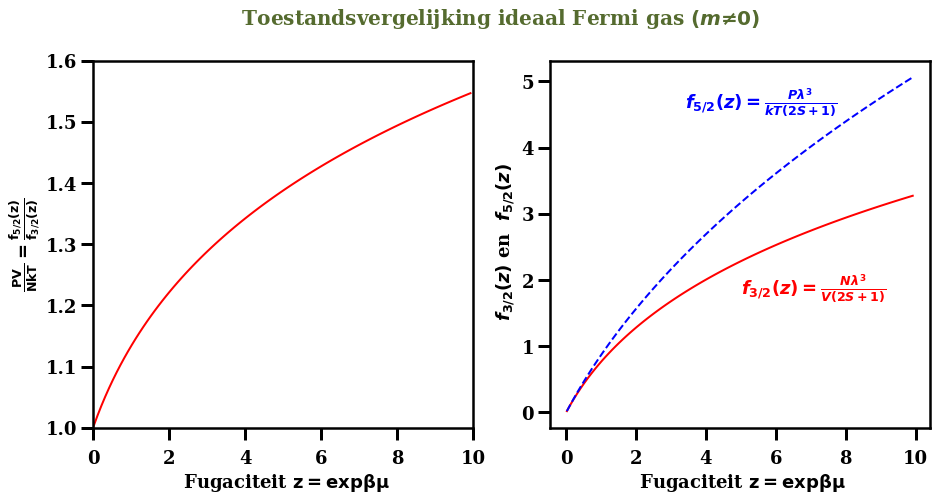

In [13]:
# figure of the EOS of an Ideal Fermi Gas as a function of the fugacity
figFermi=plt.figure(figsize=(15,7.5))
ax=figFermi.add_subplot(121)
ax.axis([0.,10.,1.0,1.6])
figFermi.subplots_adjust(bottom=0.2) # create room for x-axis label ; ,left=0.2

ax.set_xlabel(r' Fugaciteit $\bf z=\exp \beta \mu$',fontsize=18,weight='bold')
ax.set_ylabel(r'$\bf \frac {PV}{NkT}= \frac{f_{5/2}(z)}{f_{3/2}(z)}$',fontsize=18,weight='bold')
ax.plot(FUGACITY, EOS, 'r-',linewidth=2)
figFermi.suptitle(r' Toestandsvergelijking ideaal Fermi gas $(m \ne 0)$',color='darkolivegreen',fontsize=20,weight='bold')

# right panel ... f_{3/2} en f_{5/2}

ax2=figFermi.add_subplot(122)
#
ax2.set_xlabel(r' Fugaciteit $\bf z=\exp \beta \mu$',fontsize=18,weight='bold')
ax2.set_ylabel(r' $f_{3/2} (z)$ en  $f_{5/2} (z)$',fontsize=18,weight='bold')
ax2.plot(FUGACITY, F32EXACT, 'r-', FUGACITY, F52EXACT, 'b--',linewidth=2)
ax2.text(5.0, 1.8,r'${f_{3/2}(z)}=\frac {N \lambda ^3} {V (2S+1)}$',color='red',fontsize=18,fontweight='bold')
ax2.text(3.4, 4.6,r'${f_{5/2}(z)}= \frac {P \lambda ^3} {k T (2S+1)}$',color='blue',fontsize=18,fontweight='bold')
figFermi.savefig('FermiGasEOS.eps',dpi=600)
figFermi.savefig('FermiGasEOS.png')

#
plt.show(figFermi)

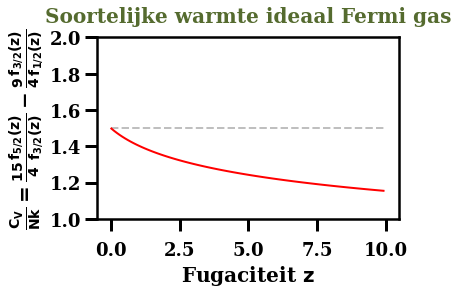

In [14]:
# Figure for Specific heat of Ideal Fermi Gas vs fugacity
figcv=plt.figure(3)
figcv.tight_layout()
figcv.subplots_adjust(left=0.2,bottom=0.25) # create room for x-axis and y-axis label
ax2a=figcv.add_subplot(111)
ax2a.plot(FUGACITY, CVoverNK, "r-", linewidth=2, label=r'Specific Heat of Ideal Bose gas')
ax2a.hlines(1.5,0.,10.,linestyles='dashed',color='grey',alpha=0.5)
ax2a.set_xlabel(r'Fugaciteit $\bf z$',weight='bold')
ax2a.set_ylabel(r'$\bf \frac{ C_V} {Nk} = \frac {15} {4} \frac {f_{5/2} (z) } {f_{3/2} (z) } - \frac {9} {4} \frac {f_{3/2} (z) } {f_{1/2} (z) }$',weight='bold')
ax2a.set_title(r'Soortelijke warmte ideaal Fermi gas',fontsize=20,y=1.05,color='darkolivegreen',weight='bold')
ax2a.set_ylim([1.,2.])
figcv.savefig('CVofIdealFermiGas.eps',dpi=600)
figcv.savefig('CVofIdealFermiGas.pdf') 

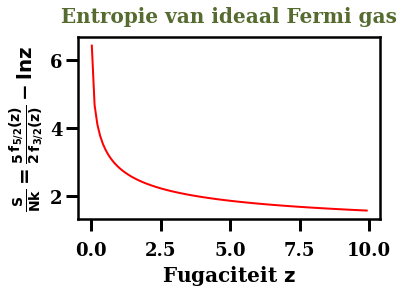

In [15]:
# Figure for Entropy of Ideal Fermi Gas vs fugacity
figS=plt.figure(4)
figS.tight_layout()
figS.subplots_adjust(left=0.2,bottom=0.25) # create room for x-axis label
ax3a=figS.add_subplot(111)
ax3a.plot(FUGACITY, SoverNK, "r-", linewidth=2, label=r'Entropy of Ideal Bose gas')
ax3a.set_xlabel(r'Fugaciteit $\bf z$',weight='bold')
ax3a.set_ylabel(r'$\bf \frac{S} {Nk} = \frac {5} {2} \frac {f_{5/2} (z) } {f_{3/2} (z) } - \ln z$',weight='bold')
ax3a.set_title(r'Entropie van ideaal Fermi gas',fontsize=20,y=1.05,color='darkolivegreen',weight='bold')
figS.savefig('SofIdealFermiGas.eps',dpi=600)
figS.savefig('SofIdealFermiGas.pdf')